# Identifying Hollow Growth Regions Using World Development Indicators

### Background
Countries often experience economic growth over time,
but improvements in income do not always lead to better health or living standards.
By studying population, Gross National Income (GNI), and life expectancy together,
policymakers can better understand whether economic progress is benefiting citizens.

### Problem Statement
Some countries have experienced economic growth without similar improvements in life expectancy,
while rapid population growth may limit the benefits of development. 

This project aims to identify these countries and support informed funding decisions.

## Objective:
*The objectives of this project are to:*

- Analyze historical trends in population, GNI per capita, and life expectancy.
- Compare countries based on these three indicators.
- Explore relationships between economic growth and human development.
- Identify countries experiencing "hollow growth."
- Provide recommendations for development funding.

## Datasets
*This project uses three world development datasets provided by Gapminder:*

- Population
- Life Expectancy
- GNI per Capita

These datasets are analyzed together to explore trends in economic and human development.

### Import Libraries

The following libraries are imported to support data manipulation, visualization, and data preprocessing throughout the exploratory data analysis (EDA).

In [1]:
# Import libraries for data manipulation
import pandas as pd

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import librarie for visualization of missing data
import missingno as msno

### Load the Datasets

The three datasets are loaded into pandas DataFrames using relative file paths. These datasets contain historical information on GNI per capita, life expectancy, and population, which will be used throughout the analysis.

In [2]:
# Load the world development datasets
GNI = pd.read_csv('./data/gni_per_cap_atlas_method_con2021.csv')
life_expectancy = pd.read_csv('./data/life_expectancy.csv')
population = pd.read_csv('./data/population.csv')

### Explore the Datasets

Before cleaning and transforming the data, each dataset is explored to understand its structure and identify any potential issues. This includes examining the first few rows, checking the dataset dimensions, reviewing the data types, and identifying missing values.

#### GNI per Capita Dataset

The GNI dataset is examined to understand its structure and quality.

In [3]:
# Display the first five rows
GNI.head()

,country,1800,1801,1802,1803,1804,1805,1806,1807,1808,...,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050
0,Afghanistan,207.0,207.0,207.0,207.0,207.0,207.0,207.0,207.0,207.0,...,751,767,783,800,817,834,852,870,888,907
1,Angola,517.0,519.0,522.0,524.0,525.0,528.0,531.0,533.0,536.0,...,2770,2830,2890,2950,3010,3080,3140,3210,3280,3340
2,Albania,207.0,207.0,207.0,207.0,207.0,207.0,207.0,207.0,207.0,...,9610,9820,10k,10.2k,10.5k,10.7k,10.9k,11.1k,11.4k,11.6k
3,United Arab Emirates,738.0,740.0,743.0,746.0,749.0,751.0,754.0,757.0,760.0,...,47.9k,48.9k,50k,51k,52.1k,53.2k,54.3k,55.5k,56.7k,57.9k
4,Argentina,794.0,797.0,799.0,802.0,805.0,808.0,810.0,813.0,816.0,...,12.8k,13.1k,13.4k,13.6k,13.9k,14.2k,14.5k,14.8k,15.2k,15.5k


In [4]:
# Display the number of rows and columns
GNI.shape

(191, 252)

In [5]:
# Display column names and data types
GNI.info()

<class 'pandas.DataFrame'>
RangeIndex: 191 entries, 0 to 190
Columns: 252 entries, country to 2050
dtypes: float64(97), str(155)
memory usage: 489.5 KB


In [6]:
# Check for missing values
GNI.isnull().sum()

country    0
1800       1
1801       1
1802       1
1803       1
          ..
2046       1
2047       1
2048       1
2049       1
2050       1
Length: 252, dtype: int64

#### Life Expectancy Dataset

The life expectancy dataset is examined to understand its structure and quality.

In [7]:
life_expectancy.head()

,country,1800,1801,1802,1803,1804,1805,1806,1807,1808,...,2091,2092,2093,2094,2095,2096,2097,2098,2099,2100
0,Afghanistan,28.2,28.2,28.2,28.2,28.2,28.2,28.1,28.1,28.1,...,75.5,75.7,75.8,76.0,76.1,76.2,76.4,76.5,76.6,76.8
1,Angola,27.0,27.0,27.0,27.0,27.0,27.0,27.0,27.0,27.0,...,78.8,79.0,79.1,79.2,79.3,79.5,79.6,79.7,79.9,80.0
2,Albania,35.4,35.4,35.4,35.4,35.4,35.4,35.4,35.4,35.4,...,87.4,87.5,87.6,87.7,87.8,87.9,88.0,88.2,88.3,88.4
3,Andorra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,United Arab Emirates,30.7,30.7,30.7,30.7,30.7,30.7,30.7,30.7,30.7,...,82.4,82.5,82.6,82.7,82.8,82.9,83.0,83.1,83.2,83.3


In [8]:
life_expectancy.info()

<class 'pandas.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Columns: 302 entries, country to 2100
dtypes: float64(301), str(1)
memory usage: 461.8 KB


In [9]:
life_expectancy.shape

(195, 302)

In [10]:
life_expectancy.isnull().sum()

country    0
1800       9
1801       9
1802       9
1803       9
          ..
2096       9
2097       9
2098       9
2099       9
2100       9
Length: 302, dtype: int64

#### Population Dataset

The population dataset is examined to understand its structure and quality.

In [11]:
population.head()

,country,1800,1801,1802,1803,1804,1805,1806,1807,1808,...,2091,2092,2093,2094,2095,2096,2097,2098,2099,2100
0,Afghanistan,3.28M,3.28M,3.28M,3.28M,3.28M,3.28M,3.28M,3.28M,3.28M,...,108M,108M,109M,109M,109M,110M,110M,110M,111M,111M
1,Angola,1.57M,1.57M,1.57M,1.57M,1.57M,1.57M,1.57M,1.57M,1.57M,...,125M,126M,127M,128M,129M,130M,131M,131M,132M,133M
2,Albania,400k,402k,404k,405k,407k,409k,411k,413k,414k,...,1.35M,1.32M,1.29M,1.26M,1.23M,1.21M,1.18M,1.15M,1.12M,1.1M
3,Andorra,2650,2650,2650,2650,2650,2650,2650,2650,2650,...,62.5k,62.2k,61.9k,61.7k,61.4k,61.2k,60.9k,60.7k,60.5k,60.2k
4,United Arab Emirates,40.2k,40.2k,40.2k,40.2k,40.2k,40.2k,40.2k,40.2k,40.2k,...,13.5M,13.5M,13.6M,13.7M,13.8M,13.8M,13.9M,14M,14M,14.1M


In [12]:
population.info()

<class 'pandas.DataFrame'>
RangeIndex: 197 entries, 0 to 196
Columns: 302 entries, country to 2100
dtypes: str(302)
memory usage: 735.3 KB


In [13]:
population.shape

(197, 302)

In [14]:
population.isnull().sum()

country    0
1800       0
1801       0
1802       0
1803       0
          ..
2096       1
2097       1
2098       1
2099       1
2100       1
Length: 302, dtype: int64

### Reshape and Clean the Datasets

The datasets are converted from wide format to long format to make them easier to merge and analyze. After reshaping, the data types are corrected and missing values are examined to ensure the datasets are ready for integration.

#### GNI per Capita

In [15]:
# Convert the dataset from wide format to long format
GNI_long = pd.melt(frame = GNI,
                    id_vars = 'country',
                    value_vars = GNI.columns.to_list()[1:], 
                    var_name = 'year',
                    value_name = 'GNI')
GNI_long.head()

,country,year,GNI
0,Afghanistan,1800,207.0
1,Angola,1800,517.0
2,Albania,1800,207.0
3,United Arab Emirates,1800,738.0
4,Argentina,1800,794.0


In [16]:
# Verify that the reshaping process was successful
GNI_long['year'].value_counts()

year
1800    191
1801    191
1802    191
1803    191
1804    191
       ... 
2046    191
2047    191
2048    191
2049    191
2050    191
Name: count, Length: 251, dtype: int64

In [17]:
GNI_long.info()

<class 'pandas.DataFrame'>
RangeIndex: 47941 entries, 0 to 47940
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   country  47941 non-null  str   
 1   year     47941 non-null  str   
 2   GNI      47712 non-null  object
dtypes: object(1), str(2)
memory usage: 1.7+ MB


In [18]:
# Convert the year column to integer
GNI_long['year'] = GNI_long['year'].astype(int)

# Convert GNI values to numeric and replace invalid values with NaN
GNI_long['GNI'] = pd.to_numeric(GNI_long['GNI'], errors='coerce')


# Verify the updated data types
GNI_long.info()

<class 'pandas.DataFrame'>
RangeIndex: 47941 entries, 0 to 47940
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   country  47941 non-null  str    
 1   year     47941 non-null  int64  
 2   GNI      42176 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.5 MB


In [19]:
GNI_long.isnull().sum()

country       0
year          0
GNI        5765
dtype: int64

#### Life Expectancy

In [20]:
# Convert the dataset from wide format to long format
life_expectancy_long = pd.melt(frame = life_expectancy,
                    id_vars = 'country',
                    value_vars = life_expectancy.columns.to_list()[1:], 
                    var_name = 'year',
                    value_name = 'life_expectancy')
life_expectancy_long.head()

,country,year,life_expectancy
0,Afghanistan,1800,28.2
1,Angola,1800,27.0
2,Albania,1800,35.4
3,Andorra,1800,NaN
4,United Arab Emirates,1800,30.7


In [21]:
life_expectancy_long['year'].value_counts()

year
1800    195
1801    195
1802    195
1803    195
1804    195
       ... 
2096    195
2097    195
2098    195
2099    195
2100    195
Name: count, Length: 301, dtype: int64

In [22]:
life_expectancy_long.info()

<class 'pandas.DataFrame'>
RangeIndex: 58695 entries, 0 to 58694
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          58695 non-null  str    
 1   year             58695 non-null  str    
 2   life_expectancy  56616 non-null  float64
dtypes: float64(1), str(2)
memory usage: 2.1 MB


In [23]:
life_expectancy_long['year'] = life_expectancy_long['year'].astype(int)
life_expectancy_long['life_expectancy'] = pd.to_numeric(life_expectancy_long['life_expectancy'], errors='coerce')
life_expectancy_long.info()

<class 'pandas.DataFrame'>
RangeIndex: 58695 entries, 0 to 58694
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          58695 non-null  str    
 1   year             58695 non-null  int64  
 2   life_expectancy  56616 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.8 MB


In [24]:
life_expectancy_long.isnull().sum()

country               0
year                  0
life_expectancy    2079
dtype: int64

#### Population

In [25]:
# Convert the dataset from wide format to long format
population_long = pd.melt(frame = population,
                    id_vars = 'country',
                    value_vars = population.columns.to_list()[1:], 
                    var_name = 'year',
                    value_name = 'population')
population_long.head()

,country,year,population
0,Afghanistan,1800,3.28M
1,Angola,1800,1.57M
2,Albania,1800,400k
3,Andorra,1800,2650
4,United Arab Emirates,1800,40.2k


In [26]:
population_long['year'].value_counts()

year
1800    197
1801    197
1802    197
1803    197
1804    197
       ... 
2096    197
2097    197
2098    197
2099    197
2100    197
Name: count, Length: 301, dtype: int64

In [27]:
population_long.info()

<class 'pandas.DataFrame'>
RangeIndex: 59297 entries, 0 to 59296
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   country     59297 non-null  str  
 1   year        59297 non-null  str  
 2   population  59197 non-null  str  
dtypes: str(3)
memory usage: 2.3 MB


#### Convert Population Values

The population dataset stores values using suffixes such as **K** (thousand), **M** (million), and **B** (billion). A custom function is created to convert these values into numeric format for analysis.

In [28]:
# Define a function to convert population values with suffixes (K, M, B) into numeric values
def parse_population(val):

    # Return missing values without modification
    if pd.isna(val):
        return val

    # Convert the value to uppercase and remove extra spaces
    val_str = str(val).strip().upper()

    # Convert millions to numeric values
    if val_str.endswith('M'):
        return float(val_str.replace('M', '')) * 1_000_000

    # Convert thousands to numeric values
    elif val_str.endswith('K'):
        return float(val_str.replace('K', '')) * 1_000

    # Convert billions to numeric values
    elif val_str.endswith('B'):
        return float(val_str.replace('B', '')) * 1_000_000_000

    # Convert values without suffixes to numeric
    return pd.to_numeric(val_str, errors='coerce')

In [29]:
population_long['year'] = population_long['year'].astype(int)
population_long['population'] = population_long['population'].apply(parse_population)
population_long.info()

<class 'pandas.DataFrame'>
RangeIndex: 59297 entries, 0 to 59296
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     59297 non-null  str    
 1   year        59297 non-null  int64  
 2   population  59197 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.8 MB


In [30]:
population_long.head()

,country,year,population
0,Afghanistan,1800,3280000.0
1,Angola,1800,1570000.0
2,Albania,1800,400000.0
3,Andorra,1800,2650.0
4,United Arab Emirates,1800,40200.0


In [31]:
population_long.isnull().sum()

country         0
year            0
population    100
dtype: int64

### Merge the Datasets

The three datasets are merged using the `country` and `year` columns to combine GNI per capita, life expectancy, and population into a single dataset for further analysis.

In [32]:
# Merge the GNI and life expectancy datasets using country and year
gni_life_df = pd.merge(left = GNI_long,
         right = life_expectancy_long,
         how = "outer",
         on = ['country','year'])
gni_life_df

,country,year,GNI,life_expectancy
0,Afghanistan,1800,207.0,28.2
1,Afghanistan,1801,207.0,28.2
2,Afghanistan,1802,207.0,28.2
3,Afghanistan,1803,207.0,28.2
4,Afghanistan,1804,207.0,28.2
...,...,...,...,...
58941,Zimbabwe,2096,NaN,73.9
58942,Zimbabwe,2097,NaN,74.0
58943,Zimbabwe,2098,NaN,74.2
58944,Zimbabwe,2099,NaN,74.3


Finally, the population dataset is merged to create a single dataset containing all three development indicators.

In [33]:
# Merge the combined GNI and life expectancy dataset with the population dataset
world_development = pd.merge( left = gni_life_df,
                              right = population_long,
                              how = 'outer',
                              on = ['country', 'year'])
world_development

,country,year,GNI,life_expectancy,population
0,Afghanistan,1800,207.0,28.2,3280000.0
1,Afghanistan,1801,207.0,28.2,3280000.0
2,Afghanistan,1802,207.0,28.2,3280000.0
3,Afghanistan,1803,207.0,28.2,3280000.0
4,Afghanistan,1804,207.0,28.2,3280000.0
...,...,...,...,...,...
59292,Zimbabwe,2096,NaN,73.9,35500000.0
59293,Zimbabwe,2097,NaN,74.0,35500000.0
59294,Zimbabwe,2098,NaN,74.2,35600000.0
59295,Zimbabwe,2099,NaN,74.3,35600000.0


### Inspect the Merged Dataset

In [34]:
world_development.shape

(59297, 5)

In [35]:
world_development.info()

<class 'pandas.DataFrame'>
RangeIndex: 59297 entries, 0 to 59296
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          59297 non-null  str    
 1   year             59297 non-null  int64  
 2   GNI              42176 non-null  float64
 3   life_expectancy  56616 non-null  float64
 4   population       59197 non-null  float64
dtypes: float64(3), int64(1), str(1)
memory usage: 2.7 MB


In [36]:
world_development.describe()

,year,GNI,life_expectancy,population
count,59297.000000,42176.000000,56616.000000,5.919700e+04
mean,1950.000000,1576.666493,53.353254,2.292217e+07
std,86.891469,1964.900566,21.320534,9.860706e+07
min,1800.000000,28.000000,1.010000,6.510000e+02
25%,1875.000000,377.000000,32.900000,4.350000e+05
50%,1950.000000,744.000000,50.000000,2.630000e+06
75%,2025.000000,1840.000000,74.000000,1.100000e+07
max,2100.000000,9990.000000,94.400000,1.700000e+09


### Create the Analysis Dataset

The project focuses on the period from **1960 to 2020**. Therefore, a new dataset is created by filtering the merged dataset to include only observations within this time range. This dataset will be used for all subsequent cleaning and exploratory data analysis.

In [37]:
# Filter rows where the year is between 1960 and 2020
analysis_df = world_development[world_development['year'].between(1960, 2020)].copy()

# Check the range and size of your new table
print(analysis_df['year'].min(), "to", analysis_df['year'].max())

1960 to 2020


### Clean the Merged Dataset

The merged dataset is inspected to identify duplicate records, evaluate missing values, and verify data quality before conducting the exploratory data analysis.

#### Check for Duplicate Records

The merged dataset is checked for duplicate records to ensure that each country-year combination appears only once before further analysis.

In [38]:
analysis_df.duplicated(subset=['country', 'year']).sum()

np.int64(0)

**Result:** No duplicate country-year records were found in the merged dataset. Therefore, no duplicate rows were removed.

#### Analyze Missing Values

The missing values are examined to understand their distribution and determine the most appropriate cleaning strategy.

In [39]:
# Count the number of missing values in each column
analysis_df.isnull().sum()

country               0
year                  0
GNI                3122
life_expectancy     131
population           20
dtype: int64

#### Investigate Missing Values

The distribution of missing values is examined to identify which variables, years, and countries have the highest amount of missing data. This helps determine the most appropriate data cleaning strategy.

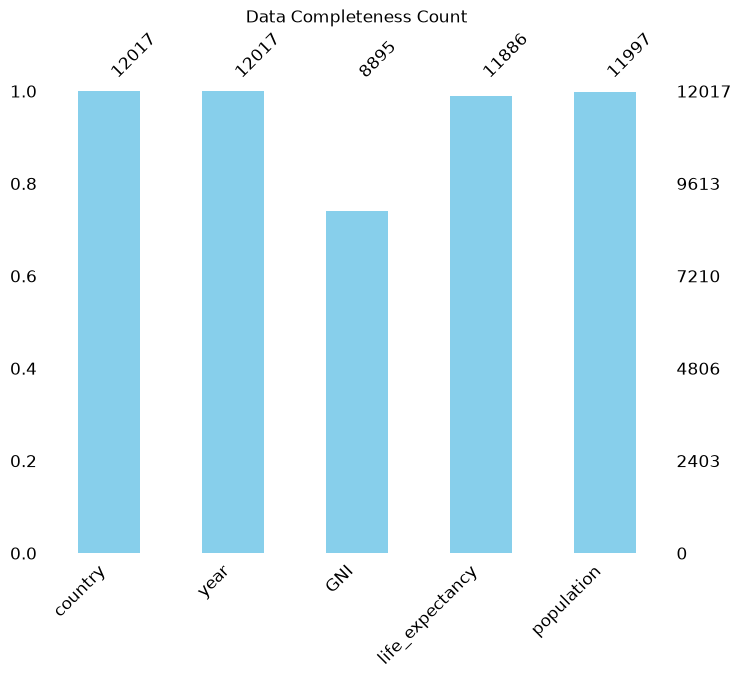

In [40]:
# Create a bar chart showing the count of missing values by column
msno.bar(analysis_df, figsize= (8,6), color=(0.53,0.81,0.92),fontsize= 12)
plt.title('Data Completeness Count')
plt.show()

In [41]:
# Count the total missing values for each year
analysis_df.isna().sum(axis=1).groupby(analysis_df['year']).sum().sort_values(ascending=False)

year
2020    81
2013    81
2014    80
2012    80
2015    78
        ..
1964    36
1962    34
1963    34
1961    32
1960    32
Length: 61, dtype: int64

In [42]:
# Count the total missing values for each country
analysis_df.isna().sum(axis=1).groupby(analysis_df['country']).sum().sort_values(ascending=False)

country
Holy See         142
Liechtenstein    122
San Marino        62
Andorra           62
Monaco            62
                ... 
Jamaica            0
Jordan             0
Kenya              0
Kiribati           0
Zimbabwe           0
Length: 197, dtype: int64

**Observations**

- GNI contains the highest number of missing values among the three indicators.
- Population contains the fewest missing values.
- The number of missing values varies across the analysis period, with 2020 having the highest count among the selected years.
- Some countries, such as Holy See, Liechtenstein, and San Marino, have a large number of missing values.

#### Handle Missing Values

The missing values are further examined to determine the most appropriate treatment before conducting the exploratory data analysis.

<Axes: >

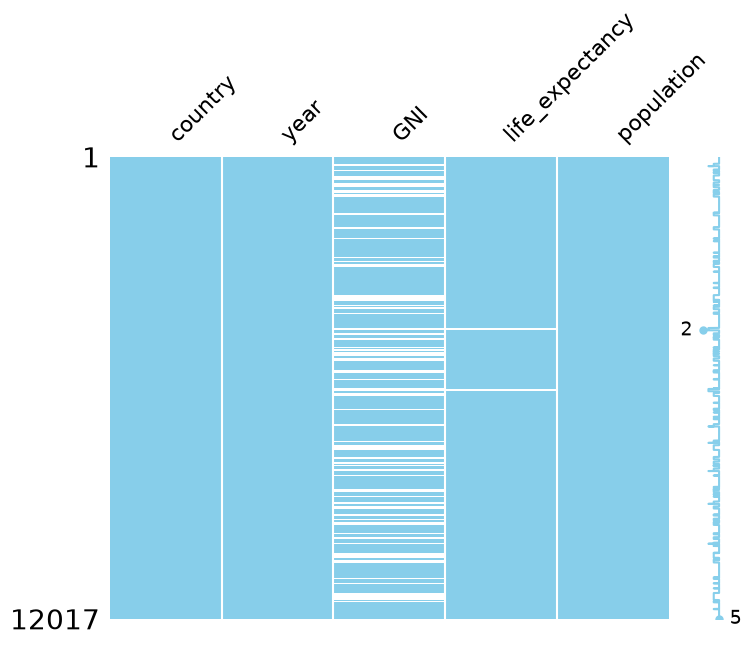

In [43]:
# Create a matrix visualization of missing values
msno.matrix(analysis_df, figsize = (8,6), color = (0.53,0.81,0.92))

**Observations**

- Most missing values are found in the `GNI` column.
- `life_expectancy` contains relatively few missing values.
- `population` is nearly complete.
- The missing values appear to be scattered across the dataset rather than concentrated in a single section.

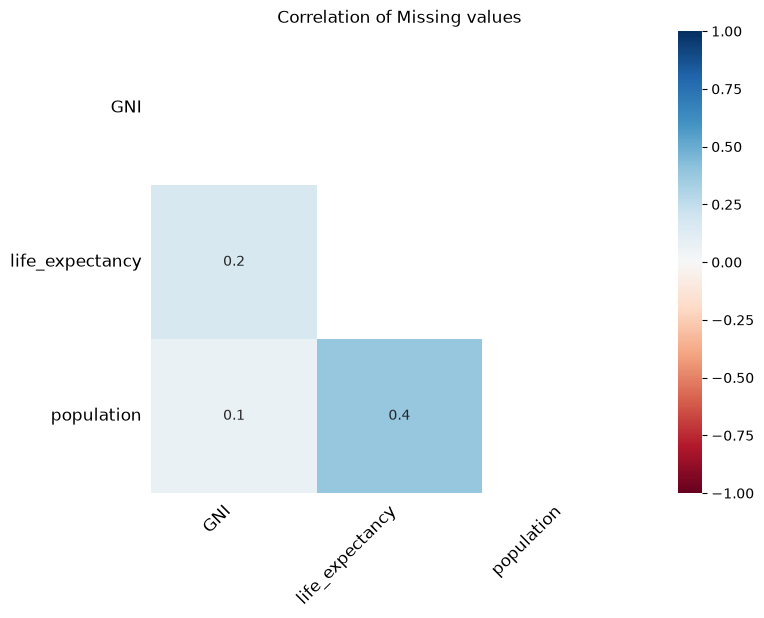

In [44]:
# Create a heatmap to show correlations between missingness
msno.heatmap(analysis_df, figsize=(8,6), fontsize=12)
plt.title('Correlation of Missing values')
plt.show()

**Observation**

The missing-value correlation heatmap shows weak to moderate relationships between the variables. No strong correlation is observed, indicating that missing values occur largely independently across the indicators.

### Missing Value Treatment Strategy

Several approaches for handling missing values were considered before cleaning the dataset. 
Although methods such as replacing missing values with the mean or median are common, they were not used in this project because the data represent yearly measurements for each country. Using a single average value could distort the historical trend of an indicator and produce unrealistic observations.

Since the objective of this study is to compare GNI, life expectancy, and population across countries over time, only complete observations were retained. Therefore, rows containing missing values in any of the required indicators were removed to ensure that the analysis is based on reliable and consistent data.

#### Remove Remaining Missing Values

The analysis requires complete information for GNI, life expectancy, and population. Therefore, observations with missing values in any of these variables are removed to ensure reliable comparisons across all development indicators.

In [45]:
# Remove rows with missing values to keep only complete observations for analysis
analysis_df = analysis_df.dropna()

# Verify that all missing values have been removed
analysis_df.isnull().sum()

country            0
year               0
GNI                0
life_expectancy    0
population         0
dtype: int64

**Result**

All remaining missing values were removed successfully. The dataset now contains complete observations for GNI, life expectancy, and population, making it ready for exploratory data analysis.

#### Verify the Cleaned Dataset

The cleaned dataset is inspected to confirm its size, review a sample of the records, and summarize the numerical variables before beginning the exploratory data analysis.

In [46]:
analysis_df.shape

(8892, 5)

In [47]:
analysis_df.head()

,country,year,GNI,life_expectancy,population
160,Afghanistan,1960,469.0,45.0,8620000.0
161,Afghanistan,1961,463.0,45.3,8790000.0
162,Afghanistan,1962,460.0,45.5,8970000.0
163,Afghanistan,1963,459.0,45.7,9160000.0
164,Afghanistan,1964,456.0,45.9,9360000.0


In [48]:
analysis_df.describe()

,year,GNI,life_expectancy,population
count,8892.000000,8892.000000,8892.000000,8.892000e+03
mean,1988.460526,2605.093905,62.447402,2.908299e+07
std,17.455515,2353.618336,9.315266,1.209076e+08
min,1960.000000,67.000000,9.500000,5.400000e+03
25%,1973.000000,739.000000,55.600000,1.467500e+06
50%,1988.000000,1700.000000,64.000000,5.290000e+06
75%,2003.000000,3780.000000,70.100000,1.580000e+07
max,2020.000000,9990.000000,80.600000,1.420000e+09


**Observation**

- The cleaned dataset contains **8,892** complete observations.
- The data covers the years **1960–2020**.
- All three development indicators (GNI, life expectancy, and population) are available for every remaining observation.
- The dataset is now ready for exploratory data analysis.

### Exploratory Data Analysis (EDA)

The cleaned dataset is explored to identify historical trends and relationships among GNI, life expectancy, and population between 1960 and 2020.
The analysis aims to provide evidence for identifying countries experiencing hollow growth and supporting funding decisions.

### Research Question 1

**How have the average GNI, life expectancy, and population changed globally between 1960 and 2020?**

#### Average GNI Over Time

This visualization shows the average Gross National Income (GNI) per country from 1960 to 2020. It provides an overview of how income levels have changed globally throughout the study period.

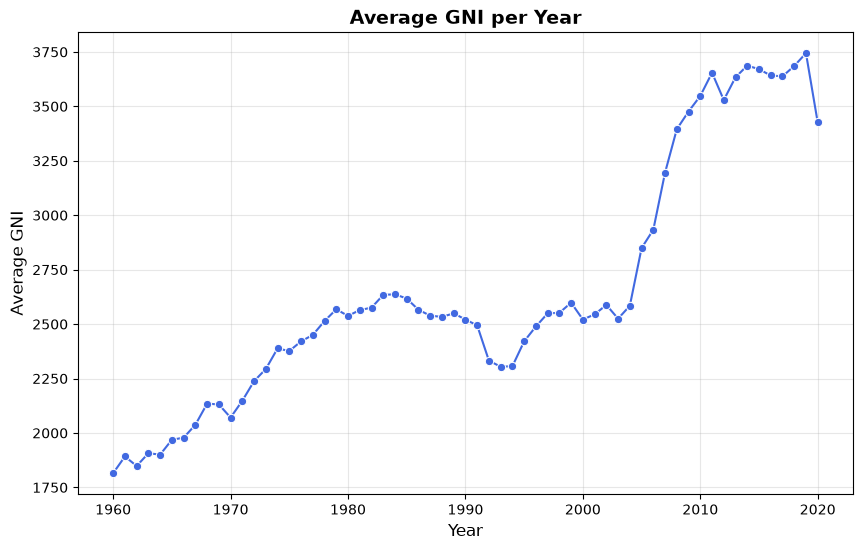

In [49]:
# Plot the average GNI for each year
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=analysis_df,
    x='year',
    y='GNI',
    estimator='mean',
    errorbar=None,
    marker='o',
    color='royalblue'
)

# Labels and title
plt.title("Average GNI per Year", fontsize=14, fontweight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average GNI", fontsize=12)

plt.grid(alpha=0.3)

plt.show()

**Observation**

The average GNI generally increased between 1960 and 2020, with gradual growth during the early decades and a more noticeable rise after the mid-2000s. A small decline is observed in the final year of the dataset.

#### Average Life Expectancy Over Time

The average life expectancy is calculated for each year to examine changes in health outcomes over time and identify long-term trends across countries.

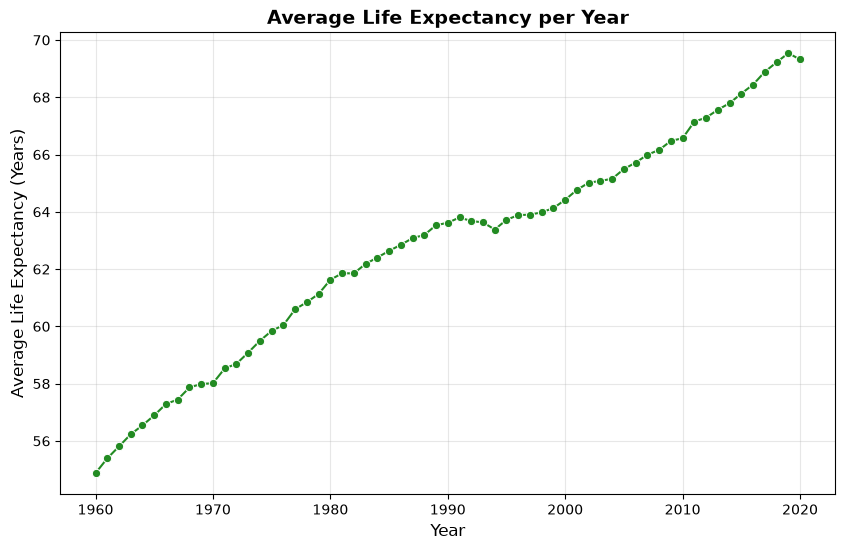

In [50]:
# Plot the average life expectancy for each year
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=analysis_df,
    x='year',
    y='life_expectancy',
    estimator='mean',
    errorbar=None,
    marker='o',
    color='forestgreen'
)

# Labels and title
plt.title("Average Life Expectancy per Year", fontsize=14, fontweight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Life Expectancy (Years)", fontsize=12)

plt.grid(alpha=0.3)

plt.show()

**Observation**

The average life expectancy increased steadily from 1960 to 2020, suggesting continuous improvements in healthcare, nutrition, sanitation, and overall living conditions across most countries.

#### Relationship Between GNI and Life Expectancy

This scatter plot examines the relationship between Gross National Income (GNI) and life expectancy across all country-year observations. A regression line is included to highlight the overall trend between economic development and health outcomes.

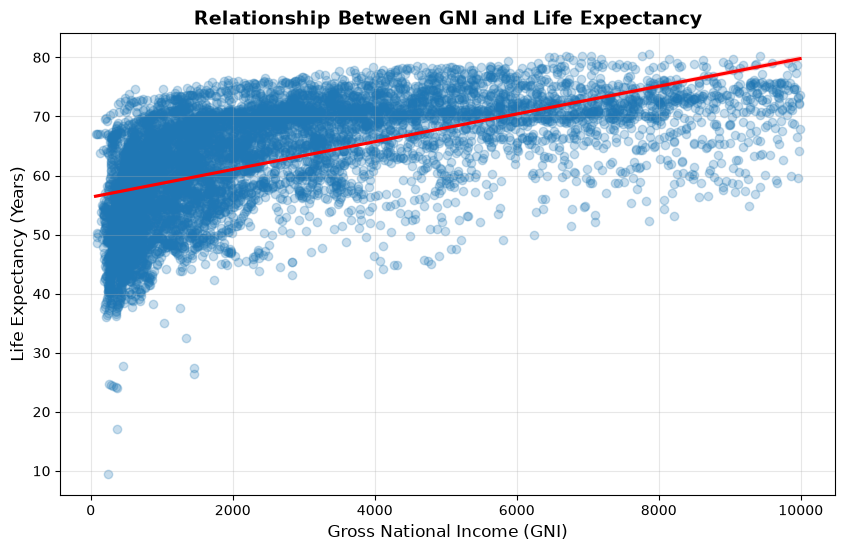

In [51]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=analysis_df,
    x='GNI',
    y='life_expectancy',
    scatter_kws={'alpha':0.25},
    line_kws={'color':'red'}
)

plt.title("Relationship Between GNI and Life Expectancy", fontsize=14, fontweight='bold')
plt.xlabel("Gross National Income (GNI)", fontsize=12)
plt.ylabel("Life Expectancy (Years)", fontsize=12)

plt.grid(alpha=0.3)
plt.show()

**Observation**

The scatter plot shows a positive relationship between GNI and life expectancy. In general, countries with higher income levels tend to have higher life expectancy. However, the wide spread of points indicates that income alone does not fully explain differences in life expectancy.

### Observation

The scatter plot shows a positive relationship between GNI and life expectancy in 2020. Countries with higher GNI generally tend to have higher life expectancy. However, several countries with moderate or relatively high GNI still have lower life expectancy than expected, indicating that higher income alone does not always result in better health outcomes. These countries may represent potential cases of hollow growth.

#### Development Change Between 1960 and 2020

To identify countries experiencing hollow growth, the changes in GNI, life expectancy, and population between 1960 and 2020 are calculated for each country. These changes provide a direct comparison of economic growth, health improvement, and population growth over the study period.

In [52]:
data_1960 = analysis_df[analysis_df['year'] == 1960]

In [53]:
data_2020 = analysis_df[analysis_df['year'] == 2020]
data_2020.head()

,country,year,GNI,life_expectancy,population
220,Afghanistan,2020,500.0,63.4,39000000.0
521,Albania,2020,5210.0,77.9,2870000.0
822,Algeria,2020,3570.0,76.2,43500000.0
1424,Angola,2020,2140.0,65.2,33400000.0
2026,Argentina,2020,9070.0,74.6,45000000.0


#### Relationship Between GNI and Life Expectancy in 2020

The scatter plot illustrates the relationship between Gross National Income (GNI) and life expectancy for all countries in 2020. This visualization helps identify whether higher income levels are generally associated with better health outcomes and highlights countries that may deviate from this pattern.

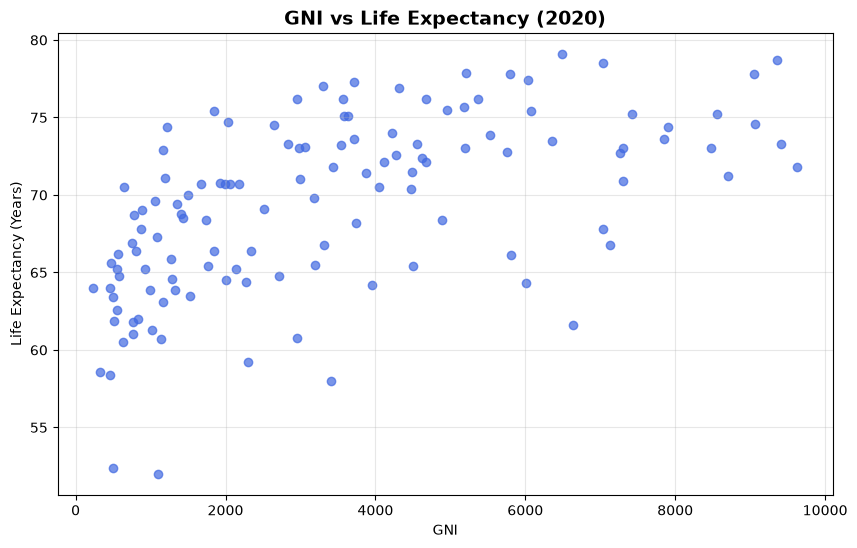

In [54]:
plt.figure(figsize=(10,6))

plt.scatter(
    data_2020['GNI'],
    data_2020['life_expectancy'],
    alpha=0.7,
    color='royalblue'
)

plt.title("GNI vs Life Expectancy (2020)", fontsize=14, fontweight='bold')
plt.xlabel("GNI")
plt.ylabel("Life Expectancy (Years)")

plt.grid(alpha=0.3)

plt.show()

### Merge 1960 and 2020 Data

The datasets for 1960 and 2020 are merged by country. This allows direct comparison of GNI, life expectancy, and population between the beginning and the end of the study period.

In [55]:
development_change = pd.merge(
    data_1960,
    data_2020,
    on='country',
    suffixes=('_1960', '_2020')
)

development_change.head()

,country,year_1960,GNI_1960,life_expectancy_1960,population_1960,year_2020,GNI_2020,life_expectancy_2020,population_2020
0,Afghanistan,1960,469.0,45.0,8620000.0,2020,500.0,63.4,39000000.0
1,Albania,1960,736.0,62.5,1710000.0,2020,5210.0,77.9,2870000.0
2,Algeria,1960,3670.0,52.4,11400000.0,2020,3570.0,76.2,43500000.0
3,Angola,1960,1720.0,46.3,5360000.0,2020,2140.0,65.2,33400000.0
4,Argentina,1960,4740.0,65.3,20300000.0,2020,9070.0,74.6,45000000.0


### Calculate Development Changes

To compare development over time, the change in GNI, life expectancy, and population is calculated for each country by subtracting the 1960 value from the 2020 value. These changes will be used to identify countries experiencing hollow growth.

In [56]:
# Calculate the change in each development indicator
development_change['GNI_change'] = (
    development_change['GNI_2020'] - development_change['GNI_1960']
)

development_change['life_expectancy_change'] = (
    development_change['life_expectancy_2020'] - development_change['life_expectancy_1960']
)

development_change['population_change'] = (
    development_change['population_2020'] - development_change['population_1960']
)

# Display the first few rows
development_change.head()

,country,year_1960,GNI_1960,life_expectancy_1960,population_1960,year_2020,GNI_2020,life_expectancy_2020,population_2020,GNI_change,life_expectancy_change,population_change
0,Afghanistan,1960,469.0,45.0,8620000.0,2020,500.0,63.4,39000000.0,31.0,18.4,30380000.0
1,Albania,1960,736.0,62.5,1710000.0,2020,5210.0,77.9,2870000.0,4474.0,15.4,1160000.0
2,Algeria,1960,3670.0,52.4,11400000.0,2020,3570.0,76.2,43500000.0,-100.0,23.8,32100000.0
3,Angola,1960,1720.0,46.3,5360000.0,2020,2140.0,65.2,33400000.0,420.0,18.9,28040000.0
4,Argentina,1960,4740.0,65.3,20300000.0,2020,9070.0,74.6,45000000.0,4330.0,9.3,24700000.0


### Explore Development Changes

Before identifying countries with hollow growth, the distributions of GNI change, life expectancy change, and population change are explored. This helps understand how development differs across countries and provides a basis for selecting appropriate criteria for identifying countries with unbalanced growth.

In [57]:
# Display summary statistics for the change variables
development_change[['GNI_change',
                    'life_expectancy_change',
                    'population_change']].describe()

,GNI_change,life_expectancy_change,population_change
count,125.000000,125.000000,1.250000e+02
mean,2186.960000,17.427200,2.811348e+07
std,2338.502731,7.756105,9.043820e+07
min,-2620.000000,-1.300000,-9.100000e+05
25%,356.000000,11.700000,1.180000e+06
50%,1665.000000,17.400000,7.700000e+06
75%,3270.000000,22.300000,2.441000e+07
max,8180.000000,41.300000,9.540000e+08


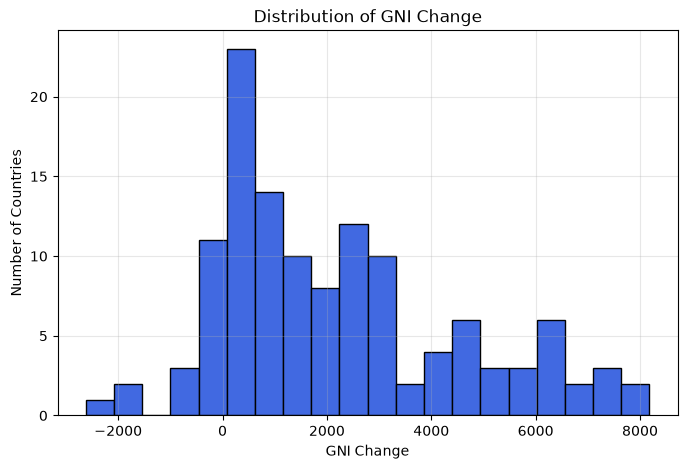

In [58]:
plt.figure(figsize=(8,5))

plt.hist(development_change['GNI_change'],
         bins=20,
         color='royalblue',
         edgecolor='black')

plt.title('Distribution of GNI Change')
plt.xlabel('GNI Change')
plt.ylabel('Number of Countries')

plt.grid(alpha=0.3)

plt.show()

The distribution shows how economic growth varies across countries. Most countries experienced positive growth in GNI, while a smaller number recorded exceptionally large increases.

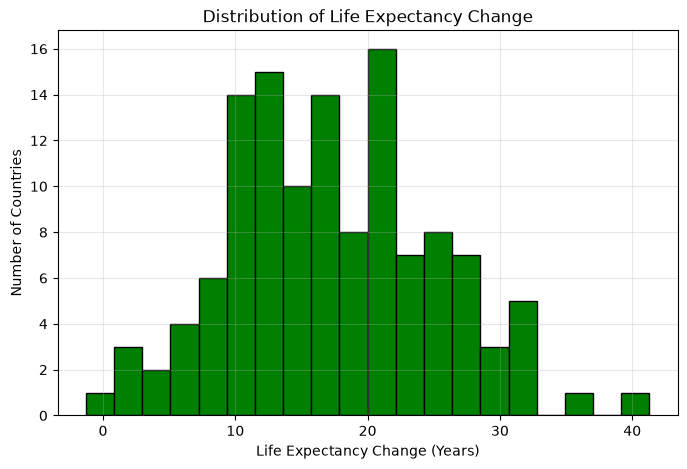

In [59]:
plt.figure(figsize=(8,5))

plt.hist(development_change['life_expectancy_change'],
         bins=20,
         color='green',
         edgecolor='black')

plt.title('Distribution of Life Expectancy Change')
plt.xlabel('Life Expectancy Change (Years)')
plt.ylabel('Number of Countries')

plt.grid(alpha=0.3)

plt.show()

Most countries experienced improvements in life expectancy between 1960 and 2020, although the amount of improvement differs across countries.

### Distribution of Population Change

The histogram shows the distribution of population growth between 1960 and 2020. This visualization helps identify whether population changes were similar across countries or if a small number of countries experienced exceptionally large increases.

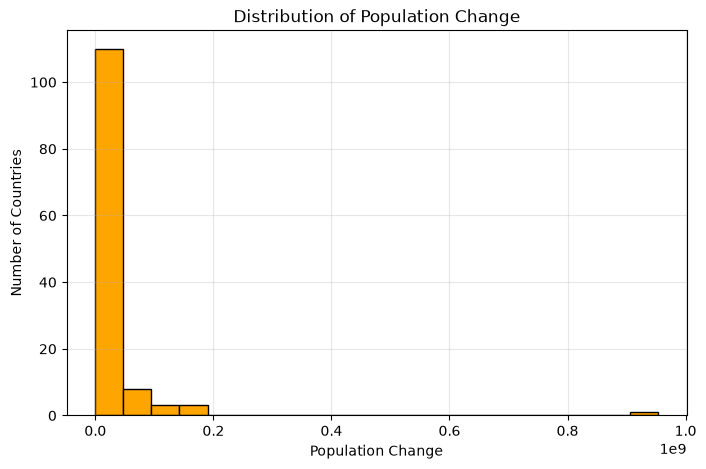

In [60]:
plt.figure(figsize=(8,5))

plt.hist(development_change['population_change'],
         bins=20,
         color='orange',
         edgecolor='black')

plt.title('Distribution of Population Change')
plt.xlabel('Population Change')
plt.ylabel('Number of Countries')

plt.grid(alpha=0.3)

plt.show()

**Observation**

The distribution is highly right-skewed, indicating that while most countries experienced moderate population growth, a small number of countries recorded exceptionally large increases. These extreme values stretch the distribution and cause most countries to appear concentrated in the lower range of the histogram.

### Define Hollow Growth Thresholds

To classify countries objectively, quartiles (Q1 and Q3) are used as data-driven thresholds instead of selecting arbitrary values.

- Countries with GNI growth above the 75th percentile (Q3) are considered to have high economic growth.
- Countries with life expectancy growth below the 25th percentile (Q1) are considered to have relatively low health improvement.
- Countries with population growth above the 75th percentile (Q3) are considered to have high population growth.

Using quartiles makes the classification consistent with the distribution of the dataset and avoids subjective threshold selection.

In [61]:
# Calculate the lower (25%) and upper (75%) quartiles for GNI change
gni_q1, gni_q3 = development_change['GNI_change'].quantile([0.25, 0.75])

# Calculate the lower and upper quartiles for life expectancy change
life_q1, life_q3 = development_change['life_expectancy_change'].quantile([0.25, 0.75])

# Calculate the lower and upper quartiles for population change
pop_q1, pop_q3 = development_change['population_change'].quantile([0.25, 0.75])

# Display the calculated thresholds
print("GNI:", gni_q1, ",", gni_q3)
print("Life Expectancy:", life_q1, ",", life_q3)
print("Population:", pop_q1, ",", pop_q3)

GNI: 356.0 , 3270.0
Life Expectancy: 11.700000000000003 , 22.299999999999997
Population: 1180000.0 , 24410000.0


### Classify Hollow Growth Countries

A custom function is used to classify each country because the classification depends on multiple conditions involving GNI growth, life expectancy change, and population growth.

Using a function makes the code:
- More organized and easier to read.
- Easier to modify if the classification rules change.
- Reusable by applying the same logic consistently to every country using `apply()`.

In [62]:
# Function to classify each country based on development changes
def classify_hollow_growth(row):

    # High GNI growth + Low life expectancy growth + High population growth
    if (
        row['GNI_change'] > gni_q3 and
        row['life_expectancy_change'] < life_q1 and
        row['population_change'] > pop_q3
    ):
        return "Hollow Growth"

    # High GNI growth + Low life expectancy growth
    elif (
        row['GNI_change'] > gni_q3 and
        row['life_expectancy_change'] < life_q1
    ):
        return "Potential Hollow Growth"

    # High GNI growth only
    elif (
        row['GNI_change'] > gni_q3
    ):
        return "Economic Growth Only"

    # All remaining countries
    else:
        return "Balanced Development"

The classification function is applied to every country in the dataset, creating a new column that stores the assigned development category.

In [63]:
# Apply the classification function to every country
development_change['Hollow_Growth'] = development_change.apply(
    classify_hollow_growth,
    axis=1
)

The table below shows the calculated changes together with the assigned development category for each country.

In [64]:
development_change[
    ['country',
     'GNI_change',
     'life_expectancy_change',
     'population_change',
     'Hollow_Growth']
].head(20)

,country,GNI_change,life_expectancy_change,population_change,Hollow_Growth
0,Afghanistan,31.0,18.4,30380000.0,Balanced Development
1,Albania,4474.0,15.4,1160000.0,Economic Growth Only
2,Algeria,-100.0,23.8,32100000.0,Balanced Development
3,Angola,420.0,18.9,28040000.0,Balanced Development
4,Argentina,4330.0,9.3,24700000.0,Hollow Growth
5,Armenia,2930.0,14.8,910000.0,Balanced Development
6,Azerbaijan,4271.0,21.8,6170000.0,Economic Growth Only
7,Bangladesh,1665.0,30.9,116600000.0,Balanced Development
8,Belarus,-780.0,2.5,1240000.0,Balanced Development
9,Belize,2070.0,8.2,303600.0,Balanced Development


### Development Category Summary

The following summary shows the number of countries in each development category after applying the hollow growth classification. This provides an overview of how countries are distributed across the different development patterns.

In [65]:
# Count the number of countries in each development category
category_counts = development_change['Hollow_Growth'].value_counts()

# Display the summary
category_counts

Hollow_Growth
Balanced Development       94
Economic Growth Only       20
Potential Hollow Growth    10
Hollow Growth               1
Name: count, dtype: int64

In [66]:
development_change[development_change['Hollow_Growth'] == 'Hollow Growth']

,country,year_1960,GNI_1960,life_expectancy_1960,population_1960,year_2020,GNI_2020,life_expectancy_2020,population_2020,GNI_change,life_expectancy_change,population_change,Hollow_Growth
4,Argentina,1960,4740.0,65.3,20300000.0,2020,9070.0,74.6,45000000.0,4330.0,9.3,24700000.0,Hollow Growth


### Development Trends for the Hollow Growth Country

GNI, population, and life expectancy are measured using different units and scales. Therefore, Min-Max normalization is applied to rescale all three indicators between 0 and 1, allowing them to be compared on the same line chart.

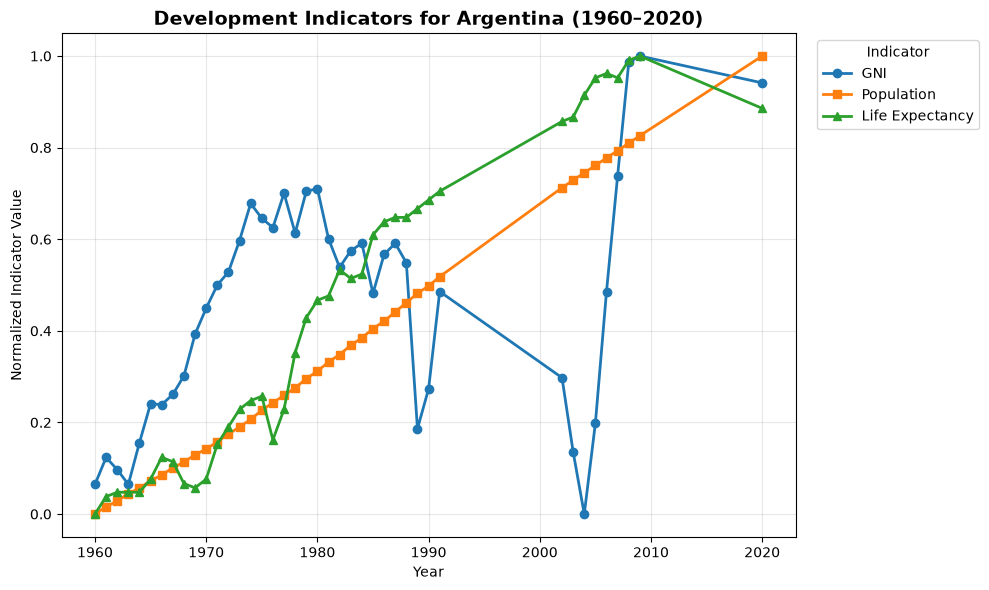

In [76]:
from sklearn.preprocessing import MinMaxScaler

# Select one country (change the name if needed)
country_name = "Argentina"

country_data = analysis_df[
    analysis_df["country"] == country_name
].copy()

# Normalize the three indicators
scaler = MinMaxScaler()

country_data[['GNI_norm',
              'Population_norm',
              'Life_norm']] = scaler.fit_transform(
    country_data[['GNI', 'population', 'life_expectancy']]
)

# Plot
plt.figure(figsize=(10,6))

plt.plot(country_data['year'],
         country_data['GNI_norm'],
         marker='o',
         linewidth=2,
         label='GNI')

plt.plot(country_data['year'],
         country_data['Population_norm'],
         marker='s',
         linewidth=2,
         label='Population')

plt.plot(country_data['year'],
         country_data['Life_norm'],
         marker='^',
         linewidth=2,
         label='Life Expectancy')

plt.title('Development Indicators for Argentina (1960–2020)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Normalized Indicator Value')
plt.legend(
    title='Indicator',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Observation

The normalized trends show that Argentina experienced substantial growth in both GNI and population between 1960 and 2020. However, life expectancy increased at a slower rate relative to the other indicators. This imbalance supports Argentina's classification as a **Hollow Growth** country, where strong economic and population growth were not matched by comparable improvements in health outcomes.

The bar chart below illustrates the distribution of countries across the four development categories.

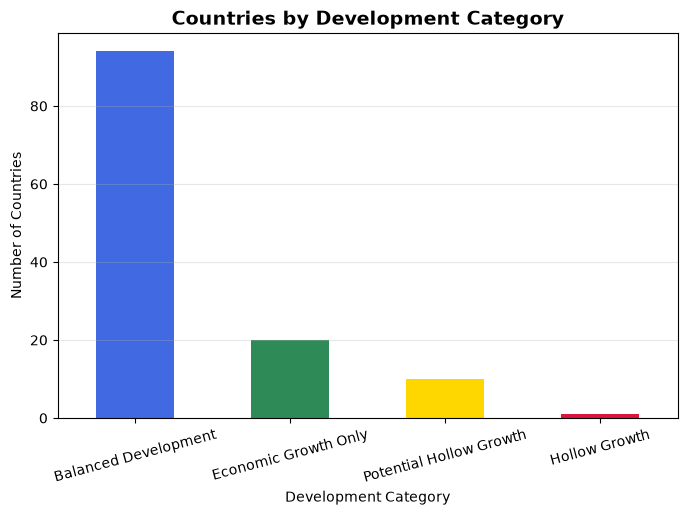

In [67]:
# Plot the number of countries in each development category
plt.figure(figsize=(8,5))

category_counts.plot(
    kind='bar',
    color=['royalblue', 'seagreen', 'gold', 'crimson']
)

plt.title("Countries by Development Category", fontsize=14, fontweight='bold')
plt.xlabel("Development Category")
plt.ylabel("Number of Countries")

plt.xticks(rotation=15)

plt.grid(axis='y', alpha=0.3)

plt.show()

### Observation

Most countries fall into the **Balanced Development** category, indicating that improvements in income, life expectancy, and population growth occurred in a relatively consistent manner. In contrast, only a limited number of countries exhibit signs of hollow growth or potential hollow growth.

# Conclusion

This analysis examined changes in Gross National Income (GNI), life expectancy, and population between 1960 and 2020 to identify countries experiencing hollow growth. By comparing development indicators over time and applying data-driven classification criteria, countries were grouped into different development categories.

The results show that most countries achieved balanced development, while a smaller number experienced strong economic growth without equivalent improvements in health outcomes. Only a very limited number of countries satisfied all conditions for hollow growth, highlighting cases where economic progress may not have translated into broader social development.

# Recommendations

Based on the analysis, the following recommendations are proposed:

- Prioritize funding for countries classified as **Hollow Growth**, where economic growth has not been matched by improvements in life expectancy.

- Closely monitor countries classified as **Potential Hollow Growth** to prevent them from developing into full hollow growth cases.

- Complement economic investment with healthcare and public health programs to ensure that income growth leads to improvements in quality of life.

- Continue monitoring development indicators regularly to support evidence-based policy decisions and effective allocation of development resources.

In [68]:
analysis_df.to_csv(
    './data/world_development_cleaned.csv',
    index=False
)

In [69]:
development_change.to_csv(
    './data/hollow_growth_analysis.csv',
    index=False
)

In [70]:
print("World Development Analysis Completed Successfully.")

World Development Analysis Completed Successfully.
